Importing libraries

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

Load and preprocess the dataset

In [2]:
# Load MNIST handwritten digit dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to range [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension (28,28) -> (28,28,1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training Shape :", x_train.shape)
print("Testing Shape  :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape : (60000, 28, 28, 1)
Testing Shape  : (10000, 28, 28, 1)


Step 2: Create noisy images

In [3]:
# Noise intensity
noise_factor = 0.4

# Generate random Gaussian noise
train_noise = np.random.normal(0, 1, x_train.shape)
test_noise = np.random.normal(0, 1, x_test.shape)

# Add noise
x_train_noisy = x_train + noise_factor * train_noise
x_test_noisy = x_test + noise_factor * test_noise

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

Displaying noisy samples

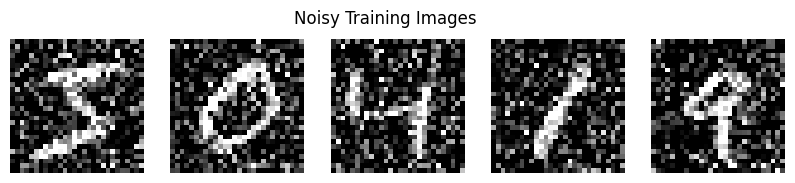

In [4]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.suptitle("Noisy Training Images")
plt.show()

Build the Denoising Autoencoder

In [5]:
# Encoder
input_img = Input(shape=(28,28,1))

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3),
                 activation='sigmoid',
                 padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Training the model

In [6]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 177s 370ms/step - loss: 0.1409 - val_loss: 0.1021
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 167s 356ms/step - loss: 0.0981 - val_loss: 0.0943
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 356ms/step - loss: 0.0935 - val_loss: 0.0924
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 169s 360ms/step - loss: 0.0912 - val_loss: 0.0896
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 165s 351ms/step - loss: 0.0897 - val_loss: 0.0886
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 352ms/step - loss: 0.0886 - val_loss: 0.0878
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 163s 347ms/step - loss: 0.0877 - val_loss: 0.0870
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 356ms/step - loss: 0.0871 - val_loss: 0.0865
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 347ms/step - loss: 0.0866 - val_loss: 0.0860
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 166s 353ms/step - loss: 0.0862 - val_loss: 0.0857


Generating denoised images

In [7]:
denoised_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


Compare the results

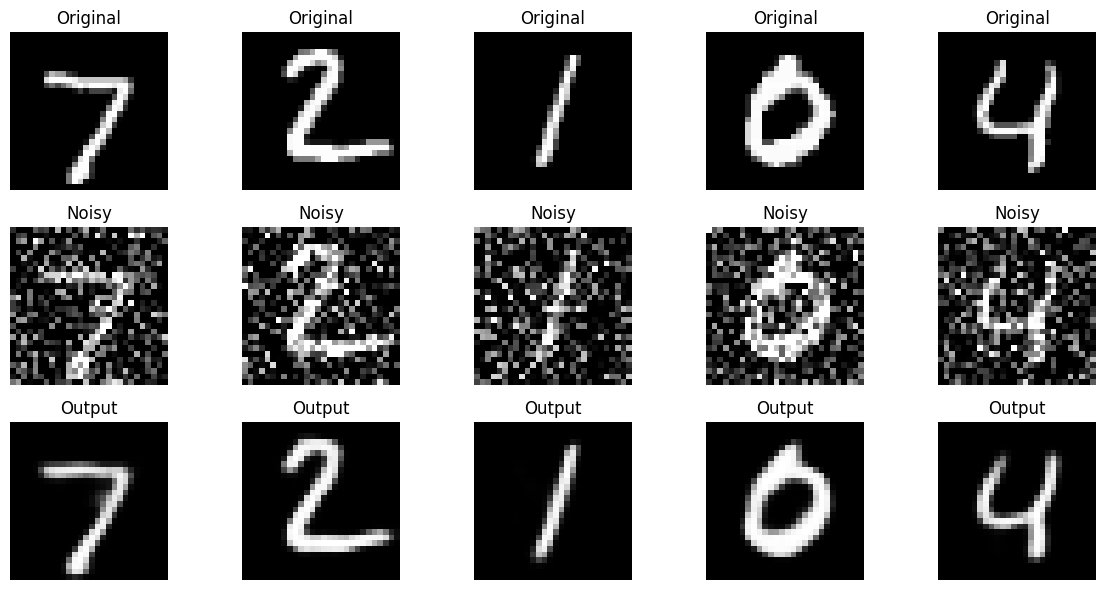

In [9]:
n = 5

plt.figure(figsize=(12,6))

for i in range(n):

    # Original image
    plt.subplot(3,n,i+1)
    3
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy image
    plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised image
    plt.subplot(3,n,i+2*n+1)
    plt.imshow(denoised_images[i].reshape(28,28), cmap="gray")
    plt.title("Output")
    plt.axis("off")

plt.tight_layout()
plt.show()